In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. NẠP DỮ LIỆU TỪ FILE EXCEL
df = pd.read_excel("data.xlsx")

# 2. TIỀN XỬ LÝ CHO MÔ HÌNH 1
# Khắc phục biến LF bị trống trước năm 1990 bằng Backward Fill
df['LF'] = df['LF'].bfill()

# Tạo biến giả Chính sách (Thắt chặt từ 1993)
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

# Tạo các biến Logarit và Sai phân để đạt tính dừng
df['Ln_GDP'] = np.log(df['GDP'])
df['d_Ln_GDP'] = df['Ln_GDP'].diff()
df['d2_Ln_GDP'] = df['d_Ln_GDP'].diff() # Gia tốc GDP
df['d_LF'] = df['LF'].diff()            # Sai phân tỷ lệ lao động nữ

# 3. LỌC DỮ LIỆU VÀ CHẠY MÔ HÌNH 1 (1987 - 2023)
# Xóa các dòng bị trống (NaN) sinh ra do lấy sai phân
df_m1 = df.dropna(subset=['TF', 'Policy_1993', 'd2_Ln_GDP', 'd_LF']).copy()

print("\n" + "="*60)
print("KẾT QUẢ MÔ HÌNH 1: TÁC ĐỘNG LỊCH SỬ CỦA CHÍNH SÁCH (1987-2023)")
print("="*60)

Y1 = df_m1['TF']
X1 = df_m1[['Policy_1993', 'd2_Ln_GDP', 'd_LF']]
X1 = sm.add_constant(X1)

# Ước lượng OLS với sai số chuẩn Newey-West (HAC)
model1 = sm.OLS(Y1, X1).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
print(model1.summary())


KẾT QUẢ MÔ HÌNH 1: TÁC ĐỘNG LỊCH SỬ CỦA CHÍNH SÁCH (1987-2023)
                            OLS Regression Results                            
Dep. Variable:                     TF   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     143.5
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           5.27e-19
Time:                        15:07:15   Log-Likelihood:                -6.0139
No. Observations:                  37   AIC:                             20.03
Df Residuals:                      33   BIC:                             26.47
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------


KẾT QUẢ MÔ HÌNH 2 (CÓ ĐỘ TRỄ 1 NĂM): TÁC ĐỘNG SAU 1 NĂM
                            OLS Regression Results                            
Dep. Variable:                     TF   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     1.527
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.242
Time:                        15:10:26   Log-Likelihood:                 34.361
No. Observations:                  22   AIC:                            -60.72
Df Residuals:                      18   BIC:                            -56.36
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

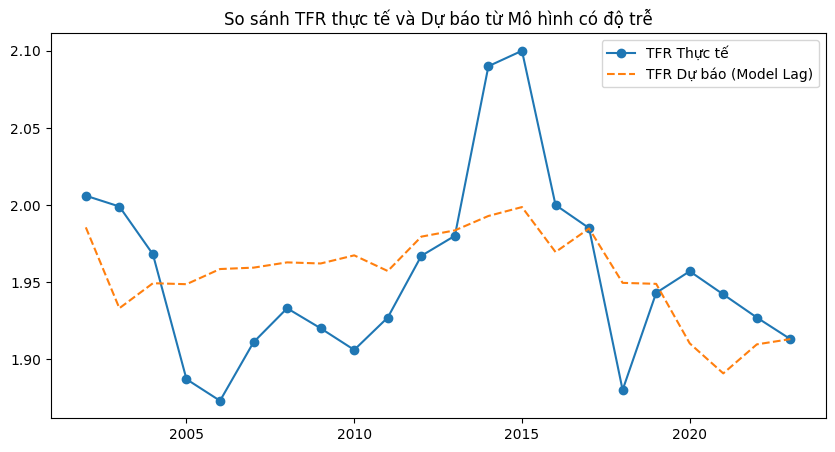

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. TẠO BIẾN ĐỘ TRỄ (LAG) 1 NĂM
# shift(1) sẽ lấy giá trị của năm trước đó gán cho năm hiện tại
df['d_UP_lag1'] = df['d_UP'].shift(1)
df['d_Hexp_lag1'] = df['d_Hexp'].shift(1)
df['d_LF_lag1'] = df['d_LF'].shift(1)

# 2. LỌC DỮ LIỆU GIAI ĐOẠN 2001 - 2023
# Sau khi lấy lag, năm 2001 sẽ bị trống do không có lag của 2000, 
# nên dữ liệu thực tế sẽ chạy từ 2002.
df_m2_lag = df[(df['Year'] >= 2000) & (df['Year'] <= 2023)].copy()
df_m2_lag = df_m2_lag.dropna(subset=['TF', 'd_UP_lag1', 'd_Hexp_lag1', 'd_LF_lag1'])

# 3. CHẠY HỒI QUY MÔ HÌNH 2 VỚI ĐỘ TRỄ
print("\n" + "="*70)
print("KẾT QUẢ MÔ HÌNH 2 (CÓ ĐỘ TRỄ 1 NĂM): TÁC ĐỘNG SAU 1 NĂM")
print("="*70)

Y2_lag = df_m2_lag['TF']
# Chúng ta thử dùng các biến có độ trễ để xem tác động muộn
X2_lag = df_m2_lag[['d_UP_lag1', 'd_Hexp_lag1', 'd_LF_lag1']]
X2_lag = sm.add_constant(X2_lag)

model2_lag = sm.OLS(Y2_lag, X2_lag).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
print(model2_lag.summary())

# 4. VẼ BIỂU ĐỒ SO SÁNH (TÙY CHỌN)
plt.figure(figsize=(10, 5))
plt.plot(df_m2_lag['Year'], Y2_lag, label='TFR Thực tế', marker='o')
plt.plot(df_m2_lag['Year'], model2_lag.predict(X2_lag), label='TFR Dự báo (Model Lag)', linestyle='--')
plt.title("So sánh TFR thực tế và Dự báo từ Mô hình có độ trễ")
plt.legend()
plt.show()

In [7]:
!pip install pmdarima


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


--- ĐANG HUẤN LUYỆN THUẬT TOÁN AUTO-ARIMAX ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   34
Model:               SARIMAX(0, 2, 0)   Log Likelihood                  42.778
Date:                Thu, 02 Apr 2026   AIC                            -83.557
Time:                        15:20:48   BIC                            -82.091
Sample:                             0   HQIC                           -83.071
                                 - 34                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0040      0.001      4.215      0.000       0.002       0.006
Ljung-Box (L1) (Q):                   1.84   Jarque-Bera (JB):                 1.44


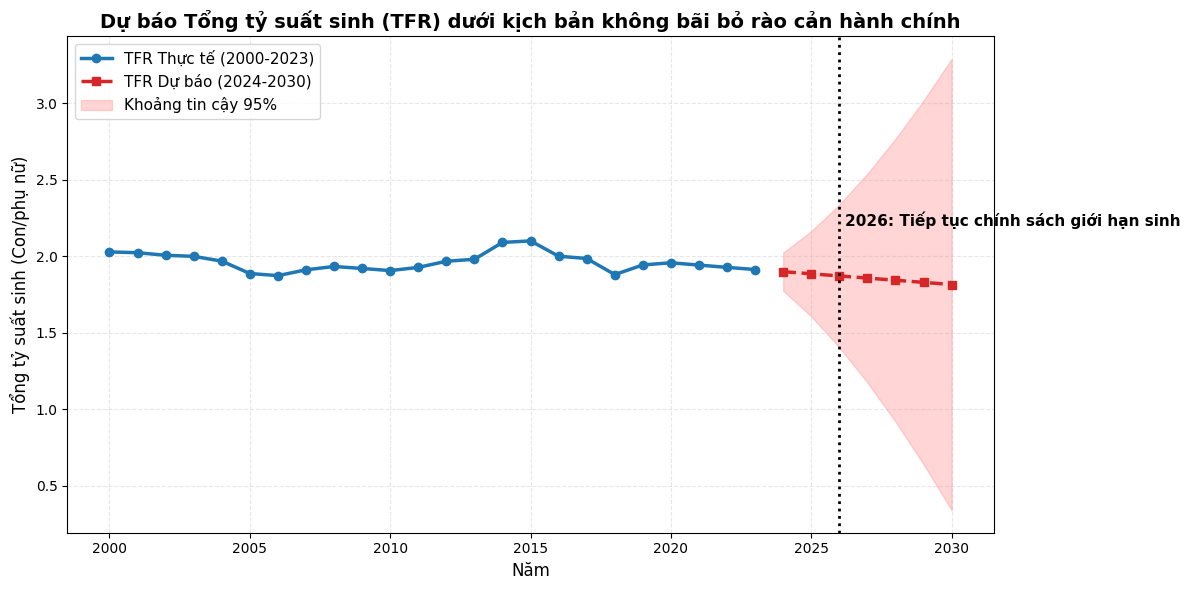


--- SỐ LIỆU TFR DỰ BÁO (2024 - 2030) ---
 Năm  TFR_Dự_báo
2024       1.899
2025       1.885
2026       1.871
2027       1.857
2028       1.843
2029       1.829
2030       1.815


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima

# 1. NẠP VÀ CHUẨN BỊ DỮ LIỆU HUẤN LUYỆN (TRAIN DATA)
df = pd.read_excel("data.xlsx")

# Tạo biến giả Chính sách như cũ
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

# Lấy dữ liệu từ 1990 đến 2023 để huấn luyện thuật toán
train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
train_df = train_df.dropna(subset=['TF', 'Policy_1993', 'UP'])

# Khai báo biến dự báo (y) và biến ngoại sinh (exog)
y_train = train_df['TF']
# Chúng ta dùng Policy (để xem tác động khi bãi bỏ) và UP (để xem áp lực đô thị)
exog_train = train_df[['Policy_1993', 'UP']] 

print("--- ĐANG HUẤN LUYỆN THUẬT TOÁN AUTO-ARIMAX ---")
# auto_arima sẽ tự động dò tìm bậc (p, d, q) tối ưu nhất cho chuỗi thời gian
model_arimax = auto_arima(y_train, exogenous=exog_train,
                          seasonal=False, stepwise=True, 
                          trace=False, error_action="ignore", suppress_warnings=True)
print(model_arimax.summary())

# 2. XÂY DỰNG KỊCH BẢN DỰ BÁO (2024 - 2030)
future_years = np.arange(2024, 2031)

# Kịch bản Chính sách: 2024-2025 vẫn giữ (1), từ 2026 bãi bỏ hoàn toàn (0)
future_policy = [1, 1, 0, 0, 0, 0, 0]

# Kịch bản Đô thị hóa (UP): Giả định tiếp tục tăng dựa trên tốc độ trung bình 5 năm cuối
last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up)) # Tốc độ tăng trung bình hàng năm
last_up = train_df['UP'].iloc[-1]
future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

# Ghép thành bảng dữ liệu tương lai
future_exog = pd.DataFrame({
    'Policy_1993': future_policy,
    'UP': future_up
}, index=future_years)

# 3. THỰC HIỆN DỰ BÁO
forecast, conf_int = model_arimax.predict(n_periods=7, exogenous=future_exog, return_conf_int=True)

# 4. TRỰC QUAN HÓA KẾT QUẢ DỰ BÁO (VẼ BIỂU ĐỒ)
plt.figure(figsize=(12, 6))

# Vẽ đường thực tế (Chỉ lấy từ năm 2000 cho dễ nhìn)
plot_df = train_df[train_df['Year'] >= 2000]
plt.plot(plot_df['Year'], plot_df['TF'], label='TFR Thực tế (2000-2023)', color='#1f77b4', linewidth=2.5, marker='o')

# Vẽ đường dự báo
plt.plot(future_years, forecast, label='TFR Dự báo (2024-2030)', color='#d62728', linestyle='--', linewidth=2.5, marker='s')

# Vẽ khoảng tin cậy 95%
plt.fill_between(future_years, conf_int[:, 0], conf_int[:, 1], color='#ff9896', alpha=0.4, label='Khoảng tin cậy 95%')

# Đánh dấu cột mốc lịch sử 2026
plt.axvline(x=2026, color='black', linestyle=':', linewidth=2)
plt.text(2026.2, max(y_train[-10:])+0.1, '2026: Tiếp tục chính sách giới hạn sinh', fontsize=11, fontweight='bold', color='black')

plt.title('Dự báo Tổng tỷ suất sinh (TFR) dưới kịch bản không bãi bỏ rào cản hành chính', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Tổng tỷ suất sinh (Con/phụ nữ)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)
plt.tight_layout()

# Lưu ảnh cực nét để dán vào Word
plt.savefig("Forecast_ARIMAX_2030.png", dpi=300)
plt.show()

# In kết quả số liệu để đưa vào bảng
forecast_df = pd.DataFrame({'Năm': future_years, 'TFR_Dự_báo': forecast.round(3)})
print("\n--- SỐ LIỆU TFR DỰ BÁO (2024 - 2030) ---")
print(forecast_df.to_string(index=False))


KẾT QUẢ HUẤN LUYỆN ARIMAX (CÓ BIẾN CHÍNH SÁCH VÀ ĐÔ THỊ HÓA)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   34
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  47.462
Date:                Thu, 02 Apr 2026   AIC                            -82.925
Time:                        15:18:47   BIC                            -73.766
Sample:                             0   HQIC                           -79.801
                                 - 34                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       0.2197      0.154      1.426      0.154      -0.082       0.522
Policy_1993     0.0199      0.067      0.297      0.766      -0.11

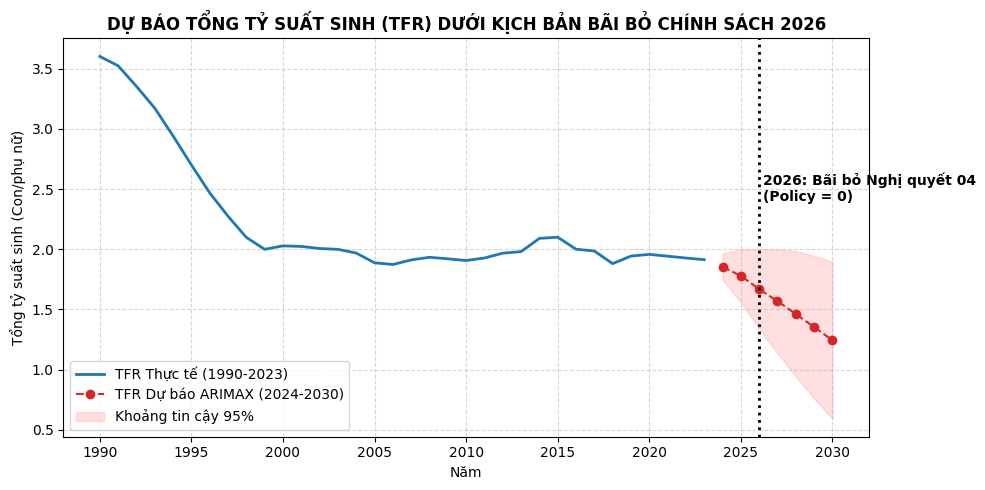


--- BẢNG SỐ LIỆU DỰ BÁO ---
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       1.855
2025                1                 39.883       1.778
2026                0                 40.759       1.668
2027                0                 41.636       1.568
2028                0                 42.512       1.462
2029                0                 43.389       1.353
2030                0                 44.265       1.244


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore") # Tắt các cảnh báo đỏ cho gọn kết quả

# 1. NẠP VÀ CHUẨN BỊ DỮ LIỆU
df = pd.read_excel("data.xlsx")

# Tạo biến giả Chính sách (1 từ 1993, 0 trước đó)
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

# Lấy dữ liệu huấn luyện từ 1990 - 2023
train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
train_df = train_df.dropna(subset=['TF', 'Policy_1993', 'UP'])

# Khai báo Y và các biến X (Ngoại sinh)
y_train = train_df['TF']
X_train = train_df[['Policy_1993', 'UP']] 

# 2. HUẤN LUYỆN MÔ HÌNH ARIMAX (Có biến ngoại sinh)
print("\n" + "="*70)
print("KẾT QUẢ HUẤN LUYỆN ARIMAX (CÓ BIẾN CHÍNH SÁCH VÀ ĐÔ THỊ HÓA)")
print("="*70)

# Thuật toán tự dò tìm cấu trúc tốt nhất
model_arimax = auto_arima(y_train, X=X_train, 
                          seasonal=False, stepwise=True, 
                          trace=False, suppress_warnings=True)
print(model_arimax.summary())

# 3. THIẾT LẬP KỊCH BẢN TƯƠNG LAI (2024 - 2030)
future_years = np.arange(2024, 2031)

# Kịch bản Chính sách: Giữ nguyên 2024-2025 (1), bãi bỏ hoàn toàn từ 2026 (0)
future_policy = [1, 1, 0, 0, 0, 0, 0]

# Kịch bản Đô thị hóa: Giả định tăng trung bình 0.5% - 0.7%/năm dựa trên quán tính cũ
last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up)) 
last_up = train_df['UP'].iloc[-1]
future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

# Tạo ma trận biến ngoại sinh cho tương lai
X_future = pd.DataFrame({'Policy_1993': future_policy, 'UP': future_up}, index=future_years)

# 4. THỰC HIỆN DỰ BÁO
forecast, conf_int = model_arimax.predict(n_periods=7, X=X_future, return_conf_int=True)

# 5. VẼ BIỂU ĐỒ DỰ BÁO TRỰC QUAN
plt.figure(figsize=(10, 5))

# TFR Thực tế
plt.plot(train_df['Year'], train_df['TF'], label='TFR Thực tế (1990-2023)', color='#1f77b4', linewidth=2)

# TFR Dự báo
plt.plot(future_years, forecast, label='TFR Dự báo ARIMAX (2024-2030)', color='#d62728', linestyle='--', marker='o')

# Vẽ vùng tin cậy 95%
plt.fill_between(future_years, conf_int[:, 0], conf_int[:, 1], color='#ff9896', alpha=0.3, label='Khoảng tin cậy 95%')

# Đánh dấu năm bãi bỏ chính sách (2026)
plt.axvline(x=2026, color='black', linestyle=':', linewidth=2)
plt.text(2026.2, max(y_train[-10:])+0.3, '2026: Bãi bỏ Nghị quyết 04\n(Policy = 0)', fontsize=10, fontweight='bold')

plt.title('DỰ BÁO TỔNG TỶ SUẤT SINH (TFR) DƯỚI KỊCH BẢN BÃI BỎ CHÍNH SÁCH 2026', fontsize=12, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Tổng tỷ suất sinh (Con/phụ nữ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 6. IN SỐ LIỆU ĐỂ BẠN LẤY BẢNG
forecast_df = pd.DataFrame({'Năm': future_years, 'Kịch bản Policy': future_policy, 'Dự báo Đô thị hóa (%)': future_up, 'TFR Dự báo': forecast})
print("\n--- BẢNG SỐ LIỆU DỰ BÁO ---")
print(forecast_df.round(3).to_string(index=False))